In [10]:
from ast import literal_eval

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel
from nnscaling.utils import compute_model_accuracy, get_device, safetensors_metadata_parser
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
model_name = "lotusroot_model"
scale_idx = "1"

In [12]:
file_path = f"/home/nsa325/work/nnscaling/model_saves/{model_name}.safetensors"

In [13]:
# Dataset config
metadata = safetensors_metadata_parser(file_path=file_path)
dataset_config = DatasetConfig(
    dataset_name=metadata["dataset"],
    num_samples=4_000,
    split="test",
    seed=21,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [14]:
model = MLP.load_model(file_path, in_features=dataset.in_features).eval()

Testing Accuracy: 0.9599999785423279


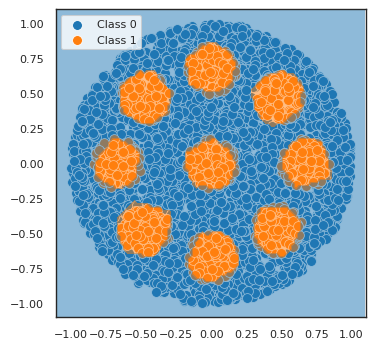

In [15]:
print(f"Testing Accuracy: {compute_model_accuracy(model.to('cpu'), dataset)}")

if dataset.in_features == 2:
    plot_decision_boundary(
        model,
        model.state_dict(),
        dataset.features,
        dataset.labels.squeeze(),
        labels=[0, 1, 2],
    )

In [16]:
file_path = f"/home/nsa325/work/nnscaling/model_saves/scaling/loc_{scale_idx}_scaled_{model_name}.safetensors"
scaled_model = ScaledModel.load_model(model, file_path).eval()

/home/nsa325/work/nnscaling/nnscaling/models/scaler.py:142: UserWarning: The `forward` method calls the `forward_scaled` method. For vanilla forward, call `forward_raw`.
  warnings.warn(
/home/nsa325/work/nnscaling/nnscaling/models/scaler.py:142: UserWarning: The `forward` method calls the `forward_scaled` method. For vanilla forward, call `forward_raw`.
  warnings.warn(


Testing Accuracy: 0.9605000019073486


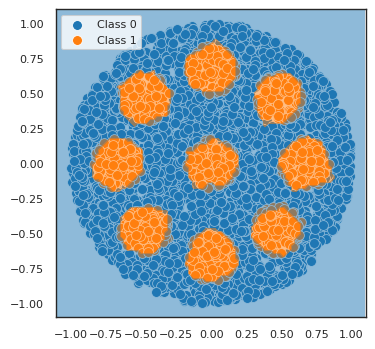

In [17]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

if dataset.in_features == 2:
    plot_decision_boundary(
        scaled_model.eval(),
        scaled_model.state_dict(),
        dataset.features,
        dataset.labels.squeeze(),
        labels=[0, 1],
    )

In [18]:
scaled_model

ScaledModel(
  (pre_inserts): Sequential(
    (0): LinearLayer(
      (linear): Linear(in_features=2, out_features=10, bias=True)
      (batchnorm_layer): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation_layer): ReLU()
    )
  )
  (scaling_layers): Sequential(
    (0): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (batchnorm_layer): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation_layer): ReLU()
    )
    (1): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (batchnorm_layer): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation_layer): ReLU()
    )
    (2): LinearLayer(
      (linear): Linear(in_features=10, out_features=8, bias=True)
      (batchnorm_layer): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation_layer): ReLU()